In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 84.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=66f086305af2368449ff92c379d2df3252100f9e46e05fd8594ffa89401d2b7c
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


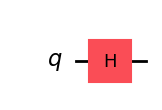

In [2]:
# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [3]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [4]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [5]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [6]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

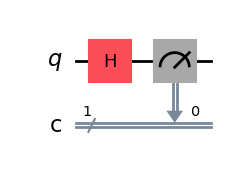

In [7]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [8]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [9]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 525, '1': 499}


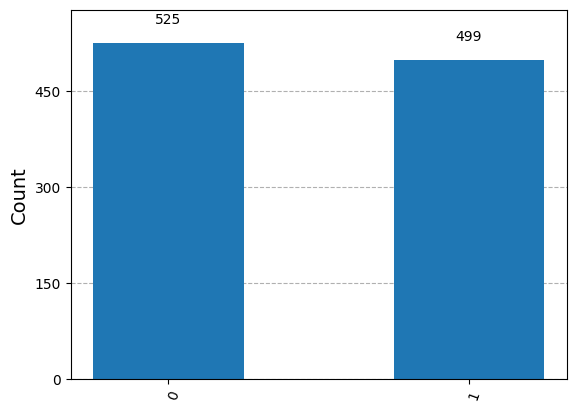

In [10]:
# We can also produce a graph

plot_histogram(counts)

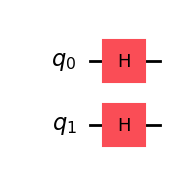

In [11]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [12]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

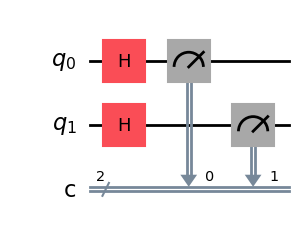

In [13]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

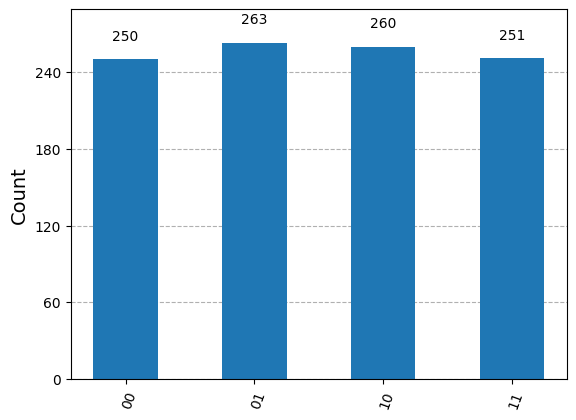

In [14]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

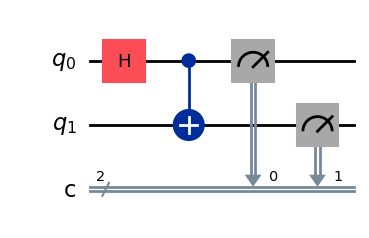

In [15]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

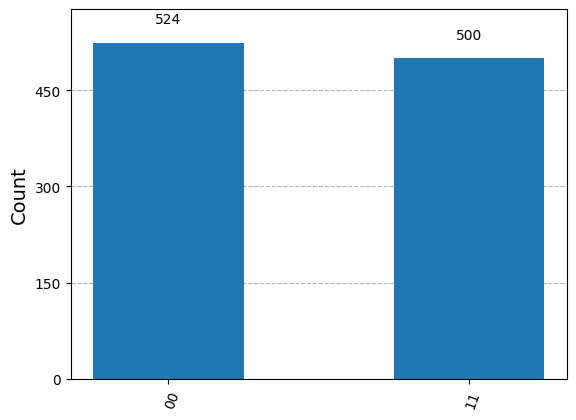

In [16]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)


Φ⁺  =  1/√2 ( |00⟩ + |11⟩ )


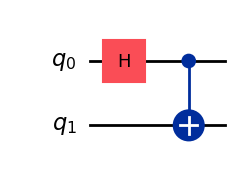

<IPython.core.display.Latex object>


Φ⁻  =  1/√2 ( |00⟩ - |11⟩ )


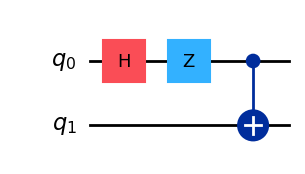

<IPython.core.display.Latex object>


Ψ⁺  =  1/√2 ( |01⟩ + |10⟩ )


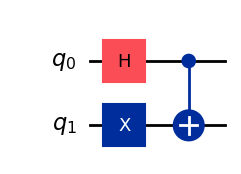

<IPython.core.display.Latex object>


Ψ⁻  =  1/√2 ( |01⟩ - |10⟩ )


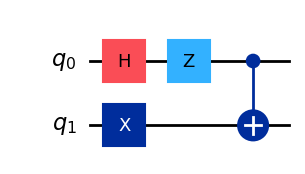

<IPython.core.display.Latex object>

In [27]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1)
circuit.measure(range(2),range(2))

# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# 1/sqrt(2) ( |00> - |11> )
circuit1 = QuantumCircuit(2, 2)
circuit1.h(0)
circuit1.z(0)      # Z creates the minus sign
circuit1.cx(0, 1)
circuit1.measure(range(2), range(2))

# 1/sqrt(2) ( |01> + |10> )
circuit2 = QuantumCircuit(2, 2)
circuit2.x(1)      # X flips qubit 1
circuit2.h(0)
circuit2.cx(0, 1)
circuit2.measure(range(2), range(2))

# 1/sqrt(2) ( |01> - |10> )
circuit3 = QuantumCircuit(2, 2)
circuit3.x(1)      # flips qubit 1
circuit3.h(0)
circuit3.z(0)      # creates minus sign
circuit3.cx(0, 1)
circuit3.measure(range(2), range(2))

# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

# ── Bell State helper ──────────────────────────────────────────
# ── Display all four state vectors ──────────────────────────────

circuits = [circuit, circuit1, circuit2, circuit3]
labels = [
    "Φ⁺  =  1/√2 ( |00⟩ + |11⟩ )",
    "Φ⁻  =  1/√2 ( |00⟩ - |11⟩ )",
    "Ψ⁺  =  1/√2 ( |01⟩ + |10⟩ )",
    "Ψ⁻  =  1/√2 ( |01⟩ - |10⟩ )",
]

for circ, label in zip(circuits, labels):
    # Remove measurements before evolving — Statevector can't handle them
    circ_no_meas = circ.remove_final_measurements(inplace=False)

    sv = Statevector.from_int(0, 4).evolve(circ_no_meas)

    print(f"\n{label}")
    display(circ_no_meas.draw("mpl"))   # show the circuit
    display(sv.draw("latex"))           # show the state vector

In [ ]:
# ── Helper used by the cells below ───────────────────────────────────────
# make_bell builds any Bell state from two boolean flags:
#   x_on_q1  – prepend X on qubit 1 (→ Ψ states)
#   z_on_q0  – insert Z on qubit 0 after H (→ minus-sign states)
#   measure  – append measurement gates

def make_bell(x_on_q1=False, z_on_q0=False, measure=False):
    qc = QuantumCircuit(2, 2) if measure else QuantumCircuit(2)
    if x_on_q1:
        qc.x(1)
    qc.h(0)
    if z_on_q0:
        qc.z(0)
    qc.cx(0, 1)
    if measure:
        qc.measure(range(2), range(2))
    return qc


In [20]:
# ── Display all four state vectors ──────────────────────────────
labels = ["Φ⁺  (|00⟩+|11⟩)", "Φ⁻  (|00⟩-|11⟩)",
          "Ψ⁺  (|01⟩+|10⟩)", "Ψ⁻  (|01⟩-|10⟩)"]
configs = [
    dict(x_on_q1=False, z_on_q0=False),   # Φ⁺
    dict(x_on_q1=False, z_on_q0=True),    # Φ⁻
    dict(x_on_q1=True,  z_on_q0=False),   # Ψ⁺
    dict(x_on_q1=True,  z_on_q0=True),    # Ψ⁻
]

for label, cfg in zip(labels, configs):
    qc = make_bell(**cfg)
    sv = Statevector.from_int(0, 4).evolve(qc)
    print(f"\n{label}")
    qc.draw("mpl")
    display(sv.draw("latex"))


Φ⁺  (|00⟩+|11⟩)


<IPython.core.display.Latex object>


Φ⁻  (|00⟩-|11⟩)


<IPython.core.display.Latex object>


Ψ⁺  (|01⟩+|10⟩)


<IPython.core.display.Latex object>


Ψ⁻  (|01⟩-|10⟩)


<IPython.core.display.Latex object>

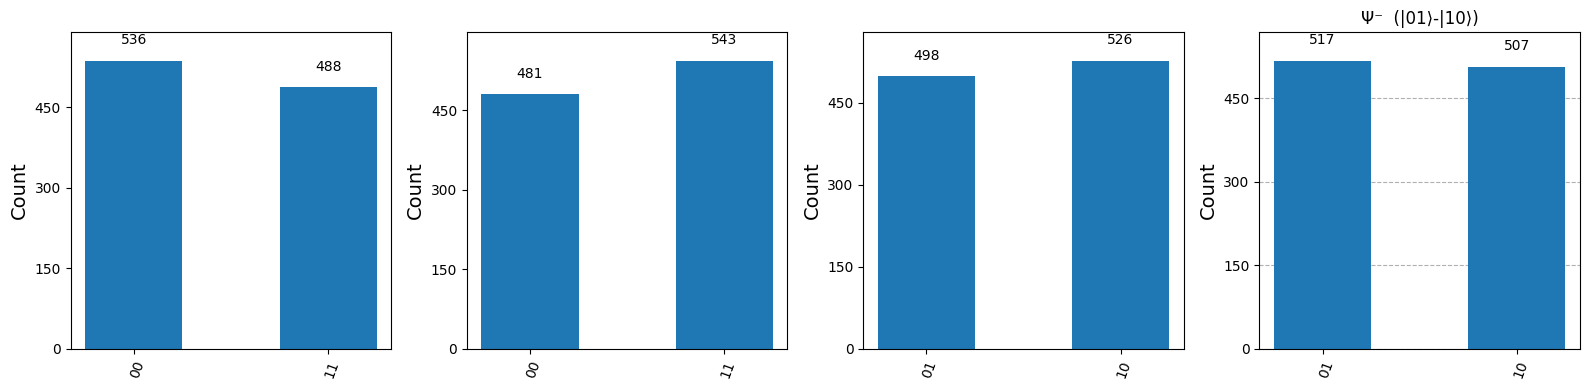

In [21]:
# ── Simulate measurements for all four Bell states ──────────────
# Φ⁺ / Φ⁻  →  results are always CORRELATED   (00 or 11)
# Ψ⁺ / Ψ⁻  →  results are always ANTI-CORRELATED (01 or 10)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

backend = BasicSimulator()

for ax, label, cfg in zip(axes, labels, configs):
    qc = make_bell(**cfg, measure=True)
    qc_t = transpile(qc, backend)
    counts = backend.run(qc_t, shots=1024).result().get_counts(qc_t)
    plot_histogram(counts, ax=ax, title=label)

plt.tight_layout()
plt.show()

In [ ]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?


# ── Imports (in case this cell is run before cell 0) ─────────────────────
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.providers.basic_provider import BasicSimulator


# ── Construction ─────────────────────────────────────────────────────────
# 1. Apply H to qubit 0  →  1/sqrt(2)(|0>+|1>) ⊗ |0...0>
# 2. Apply CNOT from qubit 0 to every other qubit.
#    Each CNOT propagates the entanglement one qubit further.

def ghz_circuit(n_qubits, measure=True):
    """Return a GHZ-state circuit for n_qubits."""
    qc = QuantumCircuit(n_qubits, n_qubits) if measure else QuantumCircuit(n_qubits)
    qc.h(0)
    for i in range(1, n_qubits):
        qc.cx(0, i)
    if measure:
        qc.measure(range(n_qubits), range(n_qubits))
    return qc


# ── Verify: display state vectors for small n ─────────────────────────────
for n in [2, 3, 4, 5]:
    qc_no_meas = ghz_circuit(n, measure=False)
    sv = Statevector.from_int(0, 2**n).evolve(qc_no_meas)
    print(f"\nGHZ state for {n} qubits:")
    display(qc_no_meas.draw("mpl"))
    display(sv.draw("latex"))


# ── Simulate measurements and probe the simulator's limits ────────────────
# GHZ measurements always give all-zeros OR all-ones — never mixed.
# BasicSimulator stores the full 2^n statevector, so it is fast up to
# ~25 qubits; beyond that RAM usage and run time grow exponentially.
import time
backend = BasicSimulator()

print("\nMeasurement results:")
for n in [2, 3, 5, 10, 15, 20, 25]:
    t0 = time.time()
    try:
        qc = ghz_circuit(n, measure=True)
        qc_t = transpile(qc, backend)
        counts = backend.run(qc_t, shots=1024).result().get_counts(qc_t)
        print(f"  {n:2d} qubits ({time.time()-t0:.1f}s): {counts}")
    except Exception as e:
        print(f"  {n:2d} qubits ({time.time()-t0:.1f}s): FAILED — {e}")
